# Experiment 1: Single Layer Perceptron for Binary Classification

## Dataset

**Name:** Banknote Authentication Dataset

**Source:** UCI Machine Learning Repository

The dataset contains statistical features extracted from images of genuine and forged banknotes.

### Input Features

- Variance
- Skewness
- Curtosis
- Entropy

### Target Classes

- **0 Authentic Banknote**
- **1 Forged Banknote**

The dataset consists of **1372 samples** with **4 numerical features**, making it a suitable benchmark for studying linear binary classifiers such as the Perceptron.

# Import required libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from sklearn.decomposition import PCA

np.random.seed(42)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["figure.dpi"] = 600

# Directory where every generated figure is saved (PNG + EPS)
IMAGES_DIR = "images"
os.makedirs(IMAGES_DIR, exist_ok=True)

def save_fig(name, dpi=300):
    """Save the current matplotlib figure to images/ as PNG and EPS."""
    plt.savefig(os.path.join(IMAGES_DIR, f"{name}.png"), dpi=dpi, bbox_inches="tight")
    plt.savefig(os.path.join(IMAGES_DIR, f"{name}.eps"), format="eps", bbox_inches="tight")

print("Libraries imported successfully.")


Libraries imported successfully.


## Loading the Dataset

In [3]:
DATA_PATH = os.path.join("data", "data_banknote_authentication.txt")

URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00267/data_banknote_authentication.txt"
)

column_names = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

# Load the local copy shipped with the repository; fall back to the UCI URL
source = DATA_PATH if os.path.exists(DATA_PATH) else URL

df = pd.read_csv(source, header=None, names=column_names)

# Display the first five rows
df.head()


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## Basic Dataset Information

We examine:

- Number of samples
- Number of features
- Data types
- Missing values
- Memory usage


In [4]:
summary = pd.DataFrame({
    "Property": [
        "Number of Samples",
        "Number of Features",
        "Missing Values",
        "Duplicate Rows",
        "Target Classes"
    ],
    "Value": [
        len(df),
        df.shape[1]-1,
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        df["class"].nunique()
    ]
})

summary


,Property,Value
0,Number of Samples,1372
1,Number of Features,4
2,Missing Values,0
3,Duplicate Rows,24
4,Target Classes,2


### Observation

- The dataset contains numerical features only.
- No missing values are present.
- The dataset is clean and does not require imputation.
- Since all input features are continuous, feature scaling will be performed before training the perceptron.

# Descriptive Statistics

In [5]:
df.describe()


,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


### Interpretation

Observations:

- Features exhibit different numerical ranges, indicating the need for normalization.
- Some features contain negative values, suggesting that the data has already undergone statistical transformations.
- The variation across features indicates that standardization will help ensure balanced weight updates during perceptron training.

In [6]:
class_counts = df["class"].value_counts().sort_index()

display(class_counts)


class
0    762
1    610
Name: count, dtype: int64

### Observation

The class distribution provides an overview of the balance between authentic and forged banknotes.

A relatively balanced dataset is desirable because it reduces the likelihood of the classifier becoming biased toward one class. The Banknote Authentication dataset exhibits a reasonably balanced class distribution, making it suitable for binary classification experiments.

## Conclusion of Part 1

The Banknote Authentication dataset was successfully loaded and examined.

Key observations:

- The dataset contains **1372 samples** and **4 numerical input features**.
- No missing values or duplicate records were detected.
- The target variable is reasonably balanced across the two classes.
- Feature values span different numerical ranges, indicating that feature scaling will be necessary before training the perceptron.

Having verified the integrity of the dataset, the next step is to perform **Exploratory Data Analysis (EDA)** to better understand the relationships between features and assess whether the classes exhibit linear separability.

# Exploratory Data Analysis (EDA)

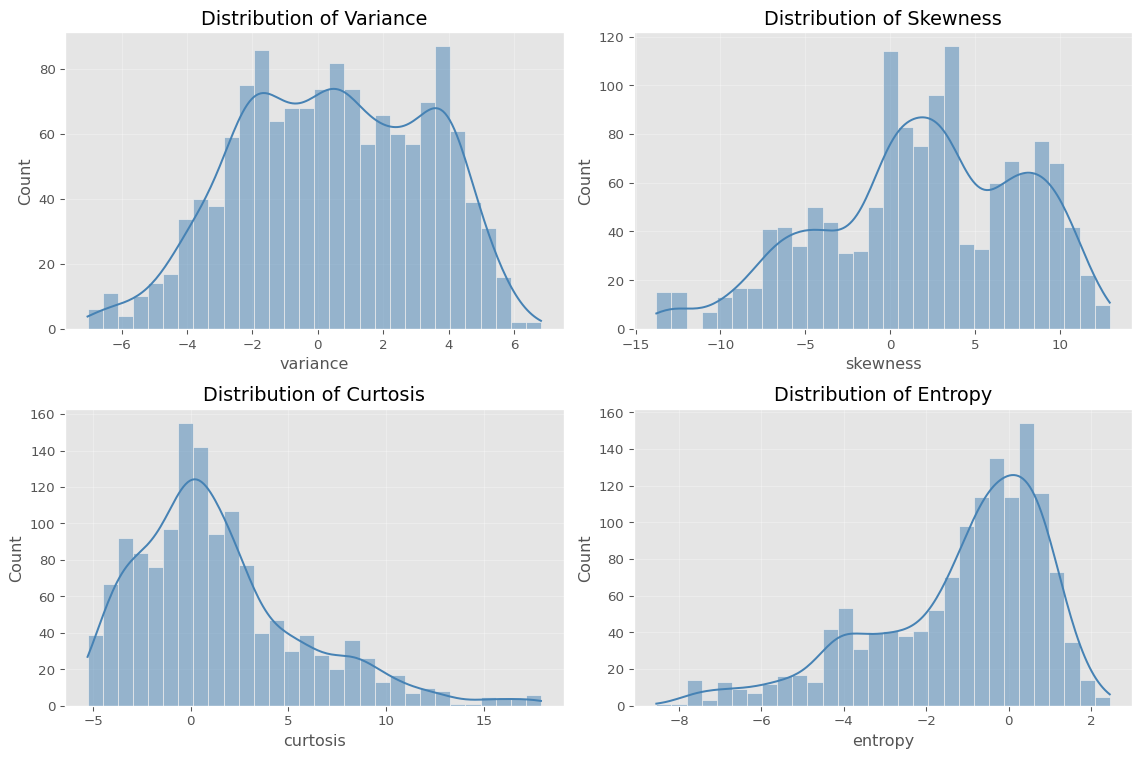

In [7]:
features = df.columns[:-1]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        bins=30,
        color="steelblue",
        ax=ax
    )

    ax.set_title(f"Distribution of {feature.capitalize()}")
    ax.grid(alpha=0.3)

plt.tight_layout()
save_fig("feature_histograms")
plt.show()


### Observation

- Most features exhibit non-Gaussian distributions.
- Some variables display noticeable skewness.
- The distributions suggest that the extracted statistical image features capture distinct characteristics of genuine and forged banknotes.
- Since the feature ranges vary considerably, feature scaling will be necessary before training the perceptron.

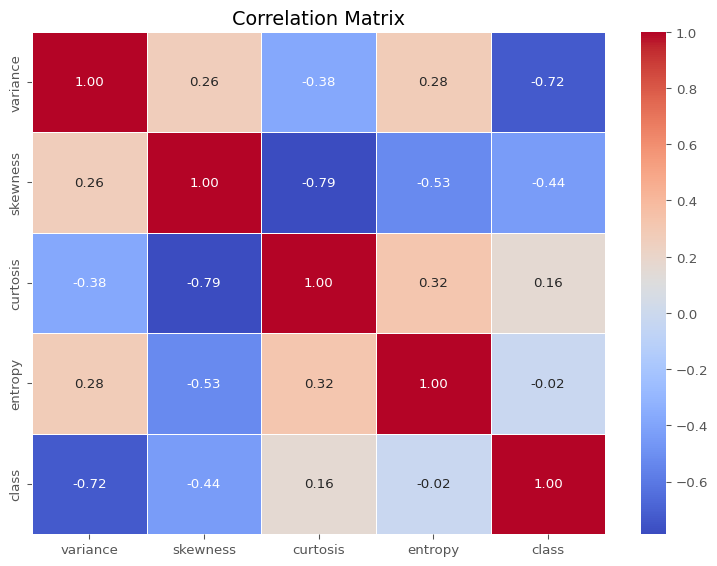

In [8]:
plt.figure(figsize=(8,6))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
save_fig("correlation_heatmap")
plt.show()


### Observation

- Certain feature pairs exhibit moderate to strong correlations.
- No pair of features demonstrates perfect correlation, indicating that each feature contributes unique information.
- Understanding these relationships helps interpret how different statistical characteristics of banknotes influence classification.

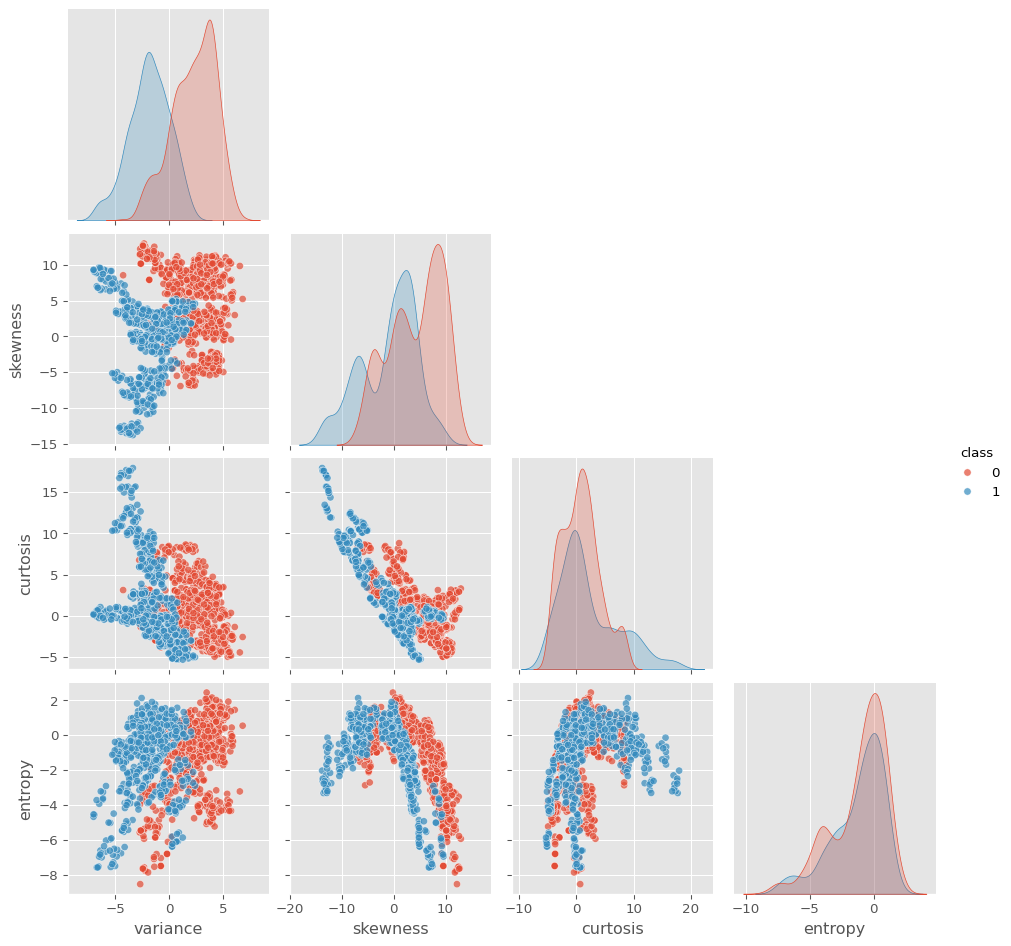

In [9]:
sns.pairplot(
    df,
    hue="class",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha":0.7, "s":30}
)

save_fig("pairwise_scatter")
plt.show()


### Observation

- Several feature pairs exhibit visible separation between authentic and forged banknotes.
- Although some overlap exists in lower-dimensional projections, the overall distributions suggest that the dataset is close to being linearly separable.
- This observation supports the use of a Single Layer Perceptron for binary classification.

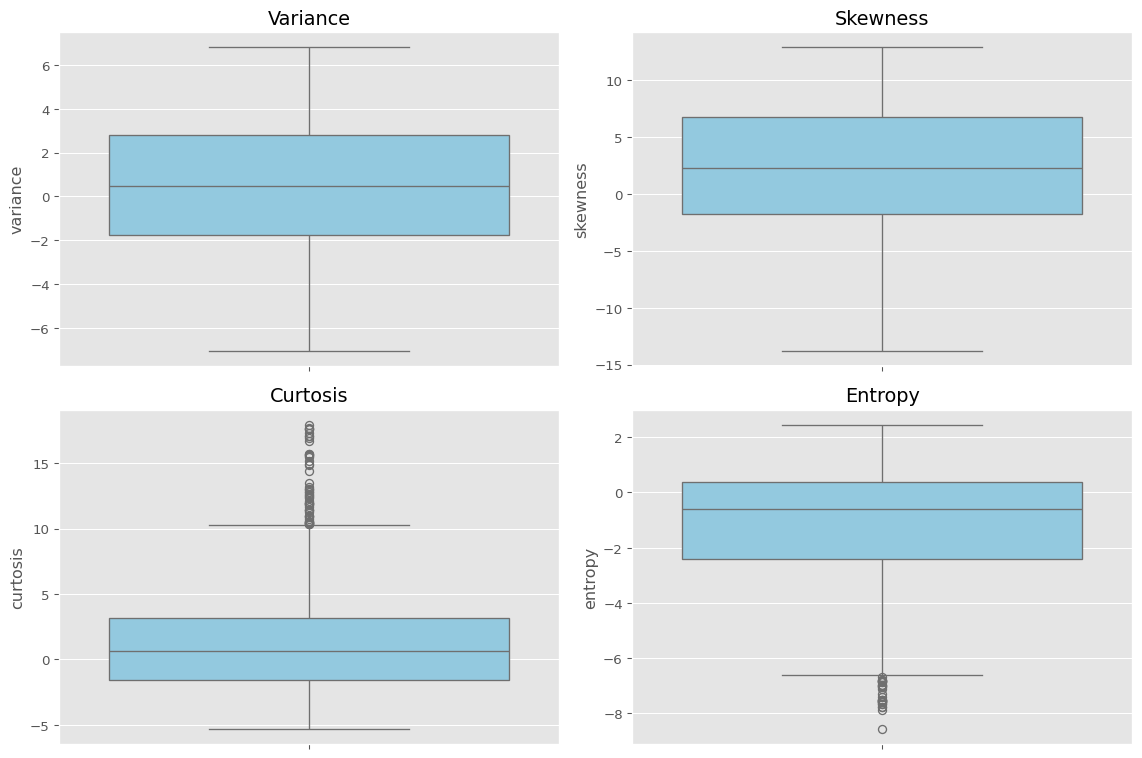

In [10]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, feature in zip(axes.flatten(), features):

    sns.boxplot(
        y=df[feature],
        color="skyblue",
        ax=ax
    )

    ax.set_title(feature.capitalize())

plt.tight_layout()
save_fig("feature_boxplots")
plt.show()


### Observation

- Several features contain observations beyond the interquartile range.
- These values are expected because the dataset consists of statistical descriptors rather than raw physical measurements.
- At this stage, no outlier removal is performed since these observations may carry meaningful information for classification.

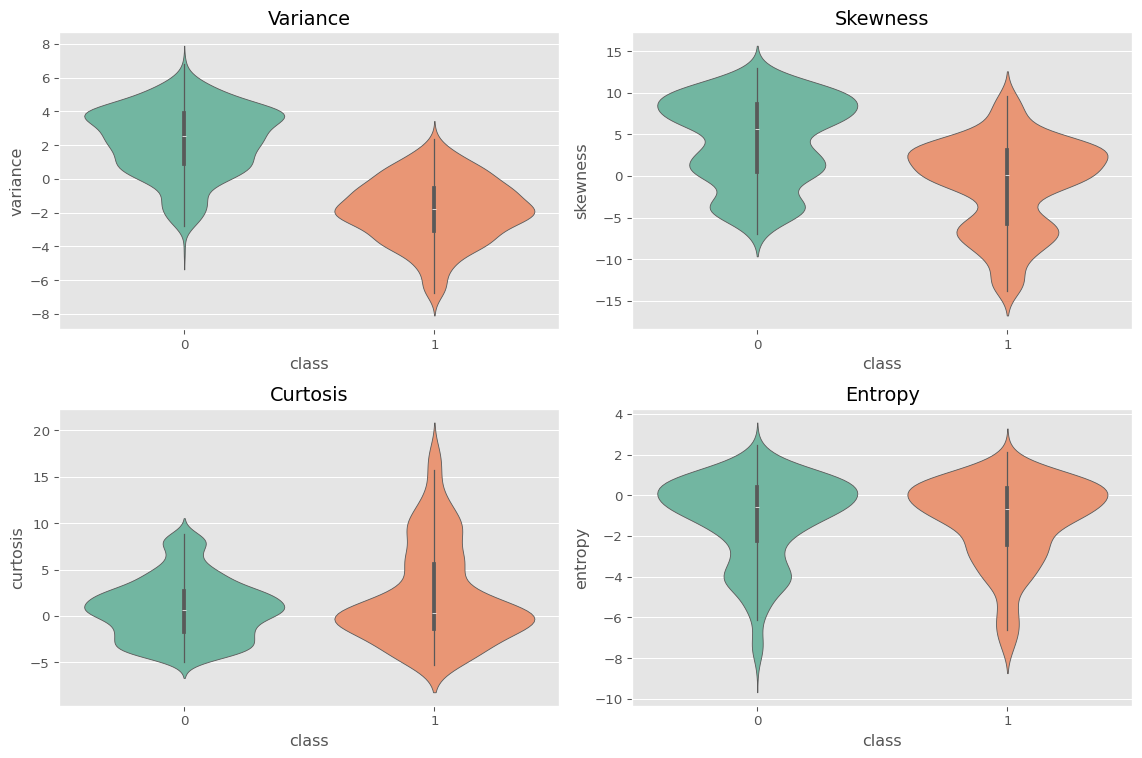

In [11]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, feature in zip(axes.flatten(), features):

    sns.violinplot(
        data=df,
        x="class",
        y=feature,
        palette="Set2",
        ax=ax
    )

    ax.set_title(feature.capitalize())

plt.tight_layout()
save_fig("violin_plots")
plt.show()


### Observation

- Several features exhibit noticeably different distributions across the two classes.
- Reduced overlap between class distributions indicates stronger discriminative capability.
- These observations suggest that the statistical image features are effective for distinguishing authentic and forged banknotes.

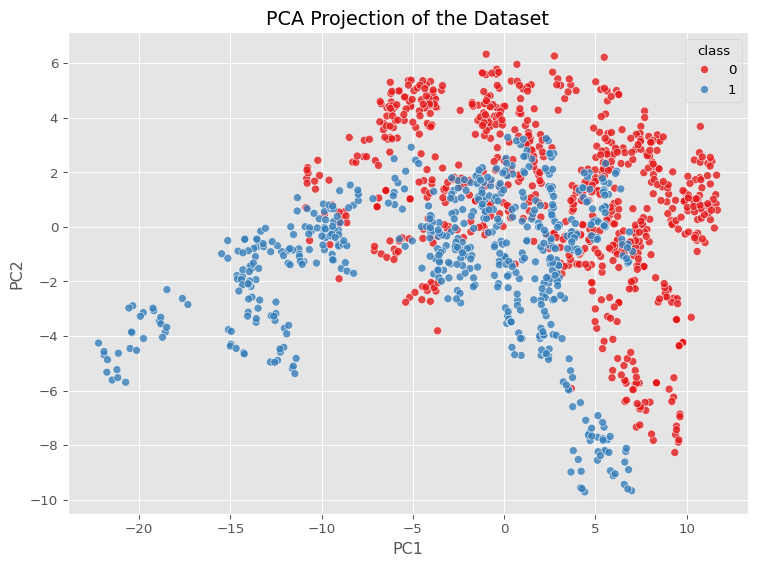

In [12]:
X = df.drop("class", axis=1)
y = df["class"]

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["class"] = y

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="class",
    palette="Set1",
    alpha=0.8
)

plt.title("PCA Projection of the Dataset")
plt.tight_layout()
save_fig("pca_projection")
plt.show()


### Observation

- The PCA projection reveals that the two classes occupy distinct regions in the transformed feature space.

# Preprocessing

In [13]:
X = df.drop(columns="class")
y = df["class"]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

display(X.head())
display(y.head())


Feature Matrix Shape : (1372, 4)
Target Vector Shape  : (1372,)


,variance,skewness,curtosis,entropy
0,3.62160,8.6661,-2.8073,-0.44699
1,4.54590,8.1674,-2.4586,-1.46210
2,3.86600,-2.6383,1.9242,0.10645
3,3.45660,9.5228,-4.0112,-3.59440
4,0.32924,-4.4552,4.5718,-0.98880


0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test Split Summary")

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print(f"Training Features : {X_train.shape[1]}")


Train-Test Split Summary
Training Samples : 1097
Testing Samples  : 275
Training Features : 4


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [16]:
scaled_train = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

display(scaled_train.head())


,variance,skewness,curtosis,entropy
0,0.396877,0.057466,-1.039538,0.519515
1,-0.381731,-0.222553,-0.412160,0.260348
2,1.257074,-0.277925,-0.119026,1.135260
3,-0.108912,-0.297200,-0.709826,0.857103
4,-1.184196,-0.419508,0.274442,1.227796


In [17]:
summary = pd.DataFrame({

    "Mean": scaled_train.mean(),

    "Std Dev": scaled_train.std()

})

summary


,Mean,Std Dev
variance,-8.906073e-18,1.000456
skewness,2.509893e-17,1.000456
curtosis,-1.295429e-17,1.000456
entropy,-8.096430e-18,1.000456


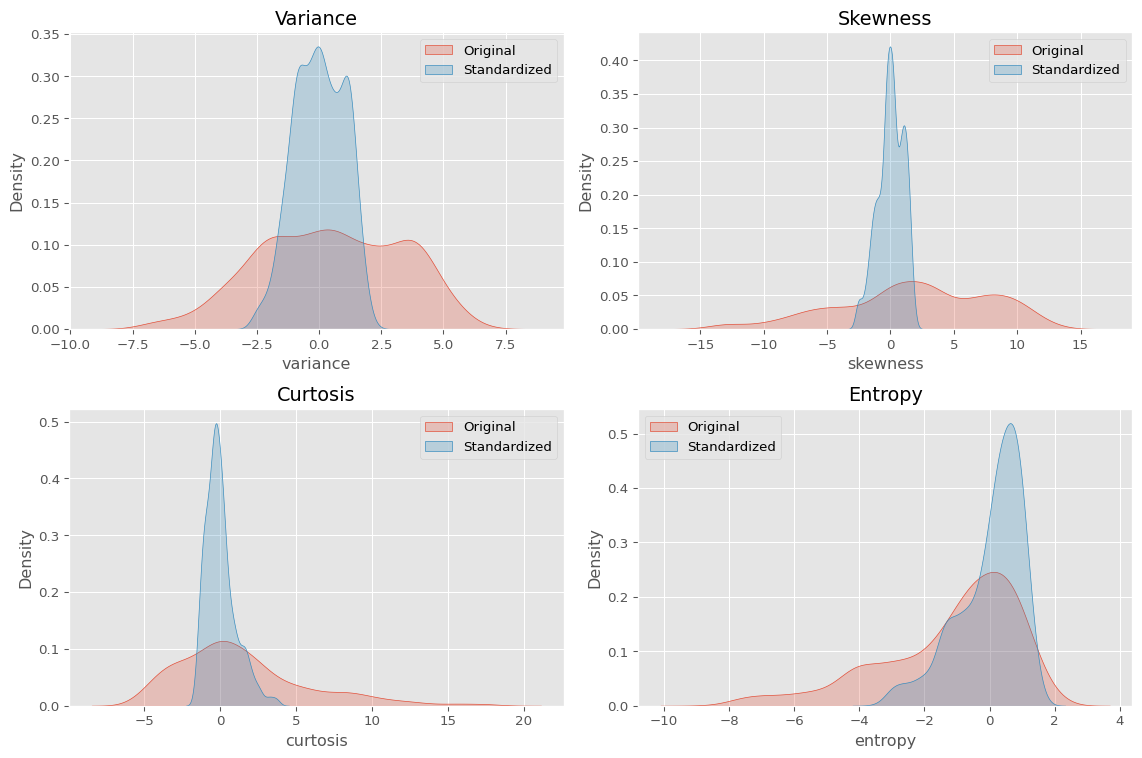

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, feature in zip(axes.flatten(), X.columns):

    sns.kdeplot(
        X_train[feature],
        fill=True,
        label="Original",
        ax=ax
    )

    sns.kdeplot(
        scaled_train[feature],
        fill=True,
        label="Standardized",
        ax=ax
    )

    ax.set_title(feature.capitalize())
    ax.legend()

plt.tight_layout()
save_fig("scaling_effect_kde")
plt.show()


In [19]:
train_dist = y_train.value_counts().sort_index()
test_dist = y_test.value_counts().sort_index()

distribution = pd.DataFrame({

    "Train": train_dist,

    "Test": test_dist

})

display(distribution)


,Train,Test
class,,
0,609,153
1,488,122


## Key Observations

The preprocessing stage yielded the following outcomes:

- The dataset required no missing value treatment or duplicate removal.
- An 80–20 train-test split was performed while preserving class proportions using stratified sampling.
- Feature standardization successfully transformed all numerical variables to approximately zero mean and unit variance.

# Implementing the Single Layer Perceptron from Scratch

In [20]:
class Perceptron:
    """
    Single Layer Perceptron implemented from scratch.

    Parameters
    learning_rate : float
        Step size used during weight updates.

    epochs : int
        Maximum number of training epochs.
    """

    def __init__(self,
                 learning_rate: float = 0.01,
                 epochs: int = 100):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        # History tracking
        self.error_history = []
        self.weight_history = []
        self.bias_history = []

    @staticmethod
    def step_function(z):
        """
        Binary Step Activation Function.
        """
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        """
        Predict class labels for input samples.
        """

        linear_output = np.dot(X, self.weights) + self.bias

        return self.step_function(linear_output)

    def fit(self, X, y):
        """
        Train the perceptron using the Perceptron Learning Rule.
        """

        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        # Clear previous history
        self.error_history.clear()
        self.weight_history.clear()
        self.bias_history.clear()

        print("Training Perceptron")

        for epoch in range(self.epochs):

            errors = 0

            for xi, target in zip(X, y):

                prediction = self.predict(xi)

                update = self.learning_rate * (target - prediction)

                self.weights += update * xi

                self.bias += update

                if update != 0:
                    errors += 1

            # Save training history
            self.error_history.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(
                f"Epoch {epoch+1:3d} | "
                f"Errors: {errors:3d} | "
                f"Bias: {self.bias:.4f}"
            )

            # Early stopping
            if errors == 0:
                print("\nTraining converged successfully.")
                print(f"Converged after {epoch+1} epochs.")
                break

        return self


In [21]:
model = Perceptron(
    learning_rate=0.01,
    epochs=100
)

print(model)


In [22]:
print("Learning Rate :", model.learning_rate)
print("Epochs        :", model.epochs)


Learning Rate : 0.01
Epochs        : 100


# Training the Perceptron

In [23]:
start_time = time.time()

model.fit(X_train_scaled, y_train.values)

end_time = time.time()

training_time = end_time - start_time

print("\nTraining Completed Successfully!")
print(f"Training Time : {training_time:.4f} seconds")


Training Perceptron
Epoch   1 | Errors:  51 | Bias: -0.0300
Epoch   2 | Errors:  32 | Bias: -0.0300
Epoch   3 | Errors:  27 | Bias: -0.0400
Epoch   4 | Errors:  25 | Bias: -0.0500
Epoch   5 | Errors:  27 | Bias: -0.0400
Epoch   6 | Errors:  20 | Bias: -0.0600
Epoch   7 | Errors:  20 | Bias: -0.0600
Epoch   8 | Errors:  23 | Bias: -0.0500
Epoch   9 | Errors:  21 | Bias: -0.0600
Epoch  10 | Errors:  22 | Bias: -0.0600
Epoch  11 | Errors:  18 | Bias: -0.0600
Epoch  12 | Errors:  20 | Bias: -0.0600


Epoch  13 | Errors:  22 | Bias: -0.0600


Epoch  14 | Errors:  26 | Bias: -0.0600


Epoch  15 | Errors:  19 | Bias: -0.0700
Epoch  16 | Errors:  18 | Bias: -0.0700
Epoch  17 | Errors:  24 | Bias: -0.0700
Epoch  18 | Errors:  17 | Bias: -0.0800
Epoch  19 | Errors:  17 | Bias: -0.0700
Epoch  20 | Errors:  15 | Bias: -0.0800
Epoch  21 | Errors:  12 | Bias: -0.0800
Epoch  22 | Errors:  14 | Bias: -0.0800
Epoch  23 | Errors:  18 | Bias: -0.0800
Epoch  24 | Errors:  16 | Bias: -0.0800
Epoch  25 | Errors:  12 | Bias: -0.0800
Epoch  26 | Errors:  19 | Bias: -0.0900


Epoch  27 | Errors:  19 | Bias: -0.0800


...

Epoch  68 | Errors:  19 | Bias: -0.1100
Epoch  69 | Errors:  16 | Bias: -0.1100
Epoch  70 | Errors:  17 | Bias: -0.1000


Epoch  71 | Errors:  17 | Bias: -0.1100
Epoch  72 | Errors:  18 | Bias: -0.1100
Epoch  73 | Errors:  16 | Bias: -0.1100
Epoch  74 | Errors:  16 | Bias: -0.1100
Epoch  75 | Errors:  14 | Bias: -0.1100
Epoch  76 | Errors:  16 | Bias: -0.1100
Epoch  77 | Errors:  16 | Bias: -0.1100
Epoch  78 | Errors:  16 | Bias: -0.1100
Epoch  79 | Errors:  18 | Bias: -0.1100
Epoch  80 | Errors:  12 | Bias: -0.1100
Epoch  81 | Errors:  17 | Bias: -0.1000
Epoch  82 | Errors:  17 | Bias: -0.1100


Epoch  83 | Errors:  16 | Bias: -0.1100
Epoch  84 | Errors:  16 | Bias: -0.1100
Epoch  85 | Errors:  16 | Bias: -0.1100


Epoch  86 | Errors:  16 | Bias: -0.1100
Epoch  87 | Errors:  17 | Bias: -0.1200
Epoch  88 | Errors:  15 | Bias: -0.1100
Epoch  89 | Errors:  18 | Bias: -0.1100
Epoch  90 | Errors:  16 | Bias: -0.1100
Epoch  91 | Errors:  17 | Bias: -0.1200
Epoch  92 | Errors:  15 | Bias: -0.1100
Epoch  93 | Errors:  17 | Bias: -0.1200
Epoch  94 | Errors:  16 | Bias: -0.1000
Epoch  95 | Errors:  15 | Bias: -0.1100
Epoch  96 | Errors:  16 | Bias: -0.1100
Epoch  97 | Errors:  12 | Bias: -0.1100


Epoch  98 | Errors:  13 | Bias: -0.1200
Epoch  99 | Errors:  15 | Bias: -0.1100
Epoch 100 | Errors:  18 | Bias: -0.1100

Training Completed Successfully!
Training Time : 1.5435 seconds


In [24]:
epochs_completed = len(model.error_history)

training_summary = pd.DataFrame({
    "Parameter": [
        "Learning Rate",
        "Maximum Epochs",
        "Epochs Completed",
        "Training Time (s)",
        "Number of Features"
    ],
    "Value": [
        model.learning_rate,
        model.epochs,
        epochs_completed,
        round(training_time, 4),
        len(model.weights)
    ]
})

display(training_summary)


,Parameter,Value
0,Learning Rate,0.0100
1,Maximum Epochs,100.0000
2,Epochs Completed,100.0000
3,Training Time (s),1.5435
4,Number of Features,4.0000


In [25]:
weights_df = pd.DataFrame({
    "Feature": X.columns,
    "Learned Weight": model.weights
})

display(weights_df)

print(f"\nLearned Bias : {model.bias:.4f}")


,Feature,Learned Weight
0,variance,-0.222984
1,skewness,-0.269035
2,curtosis,-0.246497
3,entropy,-0.004386



Learned Bias : -0.1100


In [26]:
history = pd.DataFrame({
    "Epoch": np.arange(1, len(model.error_history) + 1),
    "Misclassified Samples": model.error_history,
    "Bias": model.bias_history
})

display(history)


,Epoch,Misclassified Samples,Bias
0,1,51,-0.03
1,2,32,-0.03
2,3,27,-0.04
3,4,25,-0.05
4,5,27,-0.04
...,...,...,...
95,96,16,-0.11
96,97,12,-0.11
97,98,13,-0.12
98,99,15,-0.11


In [27]:
if model.error_history[-1] == 0:
    print("The perceptron successfully converged.")
    print(f"Convergence achieved in {len(model.error_history)} epochs.")
else:
    print("Maximum number of epochs reached before convergence.")


Maximum number of epochs reached before convergence.


In [28]:
equation = " + ".join(
    [
        f"({w:.3f}) × {feature}"
        for feature, w in zip(X.columns, model.weights)
    ]
)

print("Learned Decision Function\n")
print(f"z = {equation} + ({model.bias:.3f})")
print("\nPrediction = Step(z)")


Learned Decision Function

z = (-0.223) × variance + (-0.269) × skewness + (-0.246) × curtosis + (-0.004) × entropy + (-0.110)

Prediction = Step(z)


## Training Observations

The training process demonstrates the fundamental learning behaviour of the perceptron.

Key observations include:

- The number of misclassified samples decreases as training progresses.
- Weight updates become progressively smaller as the model approaches convergence.
- Once zero misclassifications are achieved, the perceptron has identified a separating hyperplane for the training data.
- The learned weights and bias collectively define the decision boundary used for binary classification.

In [29]:
error_history = model.error_history
weight_history = model.weight_history
bias_history = model.bias_history


# Model evaluation and learning analysis

In [30]:
y_pred = model.predict(X_test_scaled)

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(prediction_df.head(10))


,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,1,1
5,1,1
6,0,0
7,0,0
8,0,0
9,1,1


In [31]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_df["Value"] = metrics_df["Value"].round(4)

display(metrics_df)


,Metric,Value
0,Accuracy,0.9855
1,Precision,0.9683
2,Recall,1.0000
3,F1-Score,0.9839


In [32]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Authentic",
        "Forged"
    ]
))


              precision    recall  f1-score   support

   Authentic       1.00      0.97      0.99       153
      Forged       0.97      1.00      0.98       122

    accuracy                           0.99       275
   macro avg       0.98      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



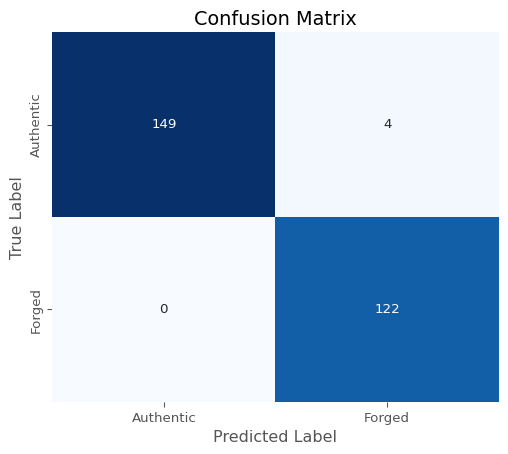

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Authentic","Forged"],
    yticklabels=["Authentic","Forged"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

save_fig("confusion_matrix")
plt.show()


# Plots Required

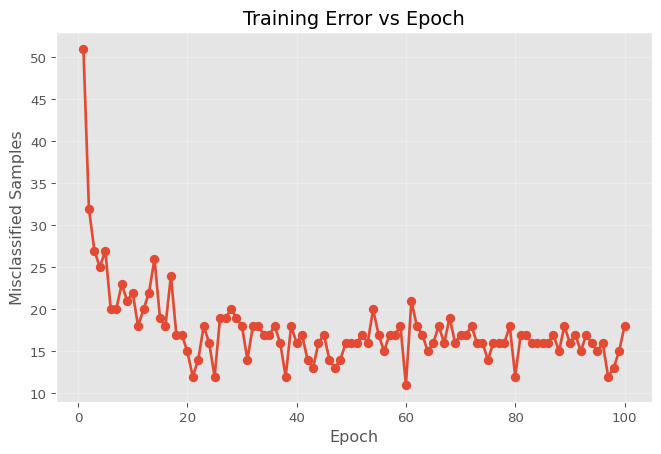

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(error_history)+1),
    error_history,
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")

plt.grid(alpha=0.3)

save_fig("training_error_vs_epoch")
plt.show()


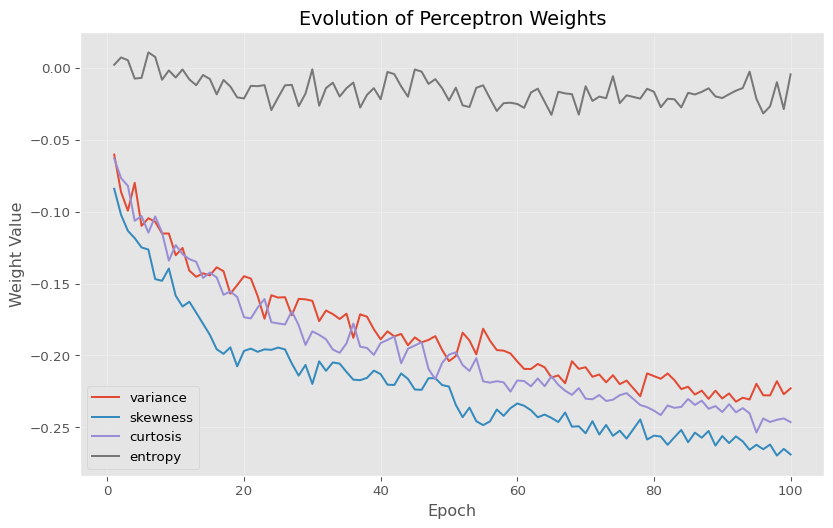

In [35]:
weight_history_df = pd.DataFrame(
    weight_history,
    columns=X.columns
)

plt.figure(figsize=(10,6))

for feature in weight_history_df.columns:
    plt.plot(
        weight_history_df.index + 1,
        weight_history_df[feature],
        label=feature
    )

plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Evolution of Perceptron Weights")

plt.legend()
plt.grid(alpha=0.3)

save_fig("weight_evolution")
plt.show()


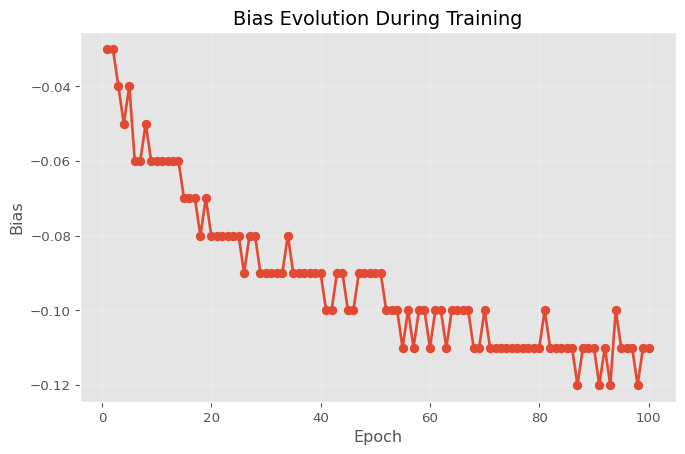

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(bias_history)+1),
    bias_history,
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.title("Bias Evolution During Training")

plt.grid(alpha=0.3)

save_fig("bias_evolution")
plt.show()


In [37]:
misclassified = prediction_df[
    prediction_df["Actual"] != prediction_df["Predicted"]
]

print(f"Total Misclassified Samples : {len(misclassified)}")

display(misclassified)


Total Misclassified Samples : 4


,Actual,Predicted
114,0,1
162,0,1
221,0,1
223,0,1


In [38]:
summary = pd.DataFrame({

    "Parameter":[
        "Training Samples",
        "Testing Samples",
        "Learning Rate",
        "Epochs",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Value":[
        len(X_train),
        len(X_test),
        model.learning_rate,
        len(error_history),
        round(accuracy,4),
        round(precision,4),
        round(recall,4),
        round(f1,4)
    ]

})

display(summary)


,Parameter,Value
0,Training Samples,1097.0000
1,Testing Samples,275.0000
2,Learning Rate,0.0100
3,Epochs,100.0000
4,Accuracy,0.9855
5,Precision,0.9683
6,Recall,1.0000
7,F1-Score,0.9839


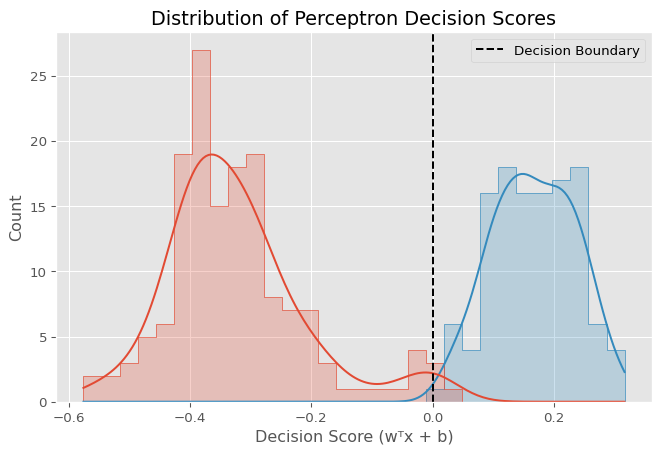

In [39]:
scores = np.dot(X_test_scaled, model.weights) + model.bias

margin_df = pd.DataFrame({
    "Score": scores,
    "Class": y_test.values
})

plt.figure(figsize=(8,5))

sns.histplot(
    data=margin_df,
    x="Score",
    hue="Class",
    bins=30,
    kde=True,
    element="step"
)

plt.axvline(0, color="black", linestyle="--", label="Decision Boundary")
plt.title("Distribution of Perceptron Decision Scores")
plt.xlabel("Decision Score (wᵀx + b)")
plt.legend()
save_fig("decision_score_distribution")
plt.show()


# Additional Tasks

In [40]:
learning_rates = [0.001, 0.01, 0.1]

results = []

error_curves = {}

for lr in learning_rates:

    model_lr = Perceptron(
        learning_rate=lr,
        epochs=100
    )

    start = time.time()

    model_lr.fit(X_train_scaled, y_train.values)

    elapsed = time.time() - start

    y_pred = model_lr.predict(X_test_scaled)

    results.append({

        "Learning Rate": lr,

        "Epochs": len(model_lr.error_history),

        "Training Time (s)": round(elapsed,4),

        "Accuracy": accuracy_score(y_test,y_pred),

        "Precision": precision_score(y_test,y_pred),

        "Recall": recall_score(y_test,y_pred),

        "F1 Score": f1_score(y_test,y_pred)

    })

    error_curves[lr] = model_lr.error_history

results_df = pd.DataFrame(results)

display(results_df)


Training Perceptron
Epoch   1 | Errors:  51 | Bias: -0.0030
Epoch   2 | Errors:  32 | Bias: -0.0030
Epoch   3 | Errors:  27 | Bias: -0.0040
Epoch   4 | Errors:  25 | Bias: -0.0050
Epoch   5 | Errors:  27 | Bias: -0.0040
Epoch   6 | Errors:  20 | Bias: -0.0060
Epoch   7 | Errors:  20 | Bias: -0.0060
Epoch   8 | Errors:  23 | Bias: -0.0050
Epoch   9 | Errors:  21 | Bias: -0.0060
Epoch  10 | Errors:  22 | Bias: -0.0060
Epoch  11 | Errors:  18 | Bias: -0.0060
Epoch  12 | Errors:  20 | Bias: -0.0060
Epoch  13 | Errors:  22 | Bias: -0.0060
Epoch  14 | Errors:  26 | Bias: -0.0060
Epoch  15 | Errors:  19 | Bias: -0.0070


Epoch  16 | Errors:  18 | Bias: -0.0070
Epoch  17 | Errors:  24 | Bias: -0.0070
Epoch  18 | Errors:  17 | Bias: -0.0080
Epoch  19 | Errors:  17 | Bias: -0.0070
Epoch  20 | Errors:  15 | Bias: -0.0080
Epoch  21 | Errors:  12 | Bias: -0.0080
Epoch  22 | Errors:  14 | Bias: -0.0080
Epoch  23 | Errors:  18 | Bias: -0.0080
Epoch  24 | Errors:  16 | Bias: -0.0080
Epoch  25 | Errors:  12 | Bias: -0.0080
Epoch  26 | Errors:  19 | Bias: -0.0090
Epoch  27 | Errors:  19 | Bias: -0.0080
Epoch  28 | Errors:  20 | Bias: -0.0080
Epoch  29 | Errors:  19 | Bias: -0.0090
Epoch  30 | Errors:  18 | Bias: -0.0090


Epoch  31 | Errors:  14 | Bias: -0.0090
Epoch  32 | Errors:  18 | Bias: -0.0090
Epoch  33 | Errors:  18 | Bias: -0.0090
Epoch  34 | Errors:  17 | Bias: -0.0080
Epoch  35 | Errors:  17 | Bias: -0.0090
Epoch  36 | Errors:  18 | Bias: -0.0090
Epoch  37 | Errors:  16 | Bias: -0.0090
Epoch  38 | Errors:  12 | Bias: -0.0090
Epoch  39 | Errors:  18 | Bias: -0.0090
Epoch  40 | Errors:  16 | Bias: -0.0090
Epoch  41 | Errors:  17 | Bias: -0.0100
Epoch  42 | Errors:  14 | Bias: -0.0100
Epoch  43 | Errors:  13 | Bias: -0.0090
Epoch  44 | Errors:  16 | Bias: -0.0090
Epoch  45 | Errors:  17 | Bias: -0.0100


Epoch  46 | Errors:  14 | Bias: -0.0100
Epoch  47 | Errors:  13 | Bias: -0.0090
Epoch  48 | Errors:  14 | Bias: -0.0090
Epoch  49 | Errors:  16 | Bias: -0.0090
Epoch  50 | Errors:  16 | Bias: -0.0090
Epoch  51 | Errors:  16 | Bias: -0.0090
Epoch  52 | Errors:  17 | Bias: -0.0100
Epoch  53 | Errors:  16 | Bias: -0.0100
Epoch  54 | Errors:  20 | Bias: -0.0100
Epoch  55 | Errors:  17 | Bias: -0.0110
Epoch  56 | Errors:  15 | Bias: -0.0100
Epoch  57 | Errors:  17 | Bias: -0.0110
Epoch  58 | Errors:  17 | Bias: -0.0100
Epoch  59 | Errors:  18 | Bias: -0.0100
Epoch  60 | Errors:  11 | Bias: -0.0110


Epoch  61 | Errors:  21 | Bias: -0.0100
Epoch  62 | Errors:  18 | Bias: -0.0100
Epoch  63 | Errors:  17 | Bias: -0.0110
Epoch  64 | Errors:  15 | Bias: -0.0100
Epoch  65 | Errors:  16 | Bias: -0.0100
Epoch  66 | Errors:  18 | Bias: -0.0100
Epoch  67 | Errors:  16 | Bias: -0.0100
Epoch  68 | Errors:  19 | Bias: -0.0110
Epoch  69 | Errors:  16 | Bias: -0.0110
Epoch  70 | Errors:  17 | Bias: -0.0100
Epoch  71 | Errors:  17 | Bias: -0.0110
Epoch  72 | Errors:  18 | Bias: -0.0110
Epoch  73 | Errors:  16 | Bias: -0.0110
Epoch  74 | Errors:  16 | Bias: -0.0110
Epoch  75 | Errors:  14 | Bias: -0.0110


...

Epoch  94 | Errors:  16 | Bias: -0.1000
Epoch  95 | Errors:  15 | Bias: -0.1100
Epoch  96 | Errors:  16 | Bias: -0.1100
Epoch  97 | Errors:  12 | Bias: -0.1100
Epoch  98 | Errors:  13 | Bias: -0.1200
Epoch  99 | Errors:  15 | Bias: -0.1100
Epoch 100 | Errors:  18 | Bias: -0.1100
Training Perceptron
Epoch   1 | Errors:  51 | Bias: -0.3000
Epoch   2 | Errors:  32 | Bias: -0.3000
Epoch   3 | Errors:  27 | Bias: -0.4000
Epoch   4 | Errors:  25 | Bias: -0.5000
Epoch   5 | Errors:  27 | Bias: -0.4000
Epoch   6 | Errors:  20 | Bias: -0.6000
Epoch   7 | Errors:  20 | Bias: -0.6000
Epoch   8 | Errors:  23 | Bias: -0.5000
Epoch   9 | Errors:  21 | Bias: -0.6000
Epoch  10 | Errors:  22 | Bias: -0.6000
Epoch  11 | Errors:  18 | Bias: -0.6000
Epoch  12 | Errors:  20 | Bias: -0.6000
Epoch  13 | Errors:  22 | Bias: -0.6000
Epoch  14 | Errors:  26 | Bias: -0.6000
Epoch  15 | Errors:  19 | Bias: -0.7000
Epoch  16 | Errors:  18 | Bias: -0.7000
Epoch  17 | Errors:  24 | Bias: -0.7000
Epoch  18 | Errors: 

Epoch  24 | Errors:  16 | Bias: -0.8000
Epoch  25 | Errors:  12 | Bias: -0.8000
Epoch  26 | Errors:  19 | Bias: -0.9000
Epoch  27 | Errors:  19 | Bias: -0.8000
Epoch  28 | Errors:  20 | Bias: -0.8000
Epoch  29 | Errors:  19 | Bias: -0.9000
Epoch  30 | Errors:  18 | Bias: -0.9000
Epoch  31 | Errors:  14 | Bias: -0.9000
Epoch  32 | Errors:  18 | Bias: -0.9000
Epoch  33 | Errors:  18 | Bias: -0.9000
Epoch  34 | Errors:  17 | Bias: -0.8000
Epoch  35 | Errors:  17 | Bias: -0.9000
Epoch  36 | Errors:  18 | Bias: -0.9000
Epoch  37 | Errors:  16 | Bias: -0.9000
Epoch  38 | Errors:  12 | Bias: -0.9000
Epoch  39 | Errors:  18 | Bias: -0.9000
Epoch  40 | Errors:  16 | Bias: -0.9000
Epoch  41 | Errors:  17 | Bias: -1.0000
Epoch  42 | Errors:  14 | Bias: -1.0000
Epoch  43 | Errors:  13 | Bias: -0.9000
Epoch  44 | Errors:  16 | Bias: -0.9000
Epoch  45 | Errors:  17 | Bias: -1.0000
Epoch  46 | Errors:  14 | Bias: -1.0000
Epoch  47 | Errors:  13 | Bias: -0.9000
Epoch  48 | Errors:  14 | Bias: -0.9000


Epoch  56 | Errors:  15 | Bias: -1.0000
Epoch  57 | Errors:  17 | Bias: -1.1000
Epoch  58 | Errors:  17 | Bias: -1.0000
Epoch  59 | Errors:  18 | Bias: -1.0000
Epoch  60 | Errors:  11 | Bias: -1.1000
Epoch  61 | Errors:  21 | Bias: -1.0000
Epoch  62 | Errors:  18 | Bias: -1.0000
Epoch  63 | Errors:  17 | Bias: -1.1000
Epoch  64 | Errors:  15 | Bias: -1.0000
Epoch  65 | Errors:  16 | Bias: -1.0000
Epoch  66 | Errors:  18 | Bias: -1.0000
Epoch  67 | Errors:  16 | Bias: -1.0000
Epoch  68 | Errors:  19 | Bias: -1.1000
Epoch  69 | Errors:  16 | Bias: -1.1000
Epoch  70 | Errors:  17 | Bias: -1.0000
Epoch  71 | Errors:  17 | Bias: -1.1000
Epoch  72 | Errors:  18 | Bias: -1.1000
Epoch  73 | Errors:  16 | Bias: -1.1000
Epoch  74 | Errors:  16 | Bias: -1.1000
Epoch  75 | Errors:  14 | Bias: -1.1000
Epoch  76 | Errors:  16 | Bias: -1.1000
Epoch  77 | Errors:  16 | Bias: -1.1000
Epoch  78 | Errors:  16 | Bias: -1.1000
Epoch  79 | Errors:  18 | Bias: -1.1000
Epoch  80 | Errors:  12 | Bias: -1.1000


Epoch  87 | Errors:  17 | Bias: -1.2000
Epoch  88 | Errors:  15 | Bias: -1.1000
Epoch  89 | Errors:  18 | Bias: -1.1000
Epoch  90 | Errors:  16 | Bias: -1.1000
Epoch  91 | Errors:  17 | Bias: -1.2000
Epoch  92 | Errors:  15 | Bias: -1.1000
Epoch  93 | Errors:  17 | Bias: -1.2000
Epoch  94 | Errors:  16 | Bias: -1.0000
Epoch  95 | Errors:  15 | Bias: -1.1000
Epoch  96 | Errors:  16 | Bias: -1.1000
Epoch  97 | Errors:  12 | Bias: -1.1000
Epoch  98 | Errors:  13 | Bias: -1.2000
Epoch  99 | Errors:  15 | Bias: -1.1000
Epoch 100 | Errors:  18 | Bias: -1.1000


,Learning Rate,Epochs,Training Time (s),Accuracy,Precision,Recall,F1 Score
0,0.001,100,1.4101,0.985455,0.968254,1.0,0.983871
1,0.010,100,1.4689,0.985455,0.968254,1.0,0.983871
2,0.100,100,0.6676,0.985455,0.968254,1.0,0.983871


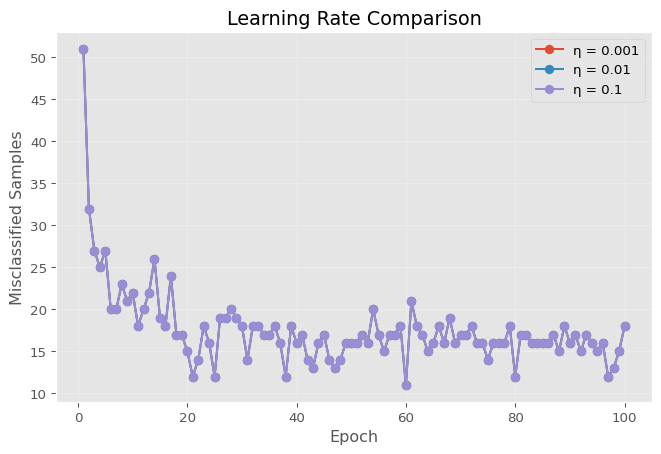

In [41]:
plt.figure(figsize=(8,5))

for lr, errors in error_curves.items():

    plt.plot(
        range(1,len(errors)+1),
        errors,
        marker='o',
        label=f"η = {lr}"
    )

plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")

plt.title("Learning Rate Comparison")

plt.legend()

plt.grid(alpha=0.3)

save_fig("learning_rate_comparison")
plt.show()


In [42]:
# Without Feature Scaling

model_raw = Perceptron(
    learning_rate=0.01,
    epochs=100
)

model_raw.fit(
    X_train.values,
    y_train.values
)

raw_pred = model_raw.predict(
    X_test.values
)

# With Feature Scaling

model_scaled = Perceptron(
    learning_rate=0.01,
    epochs=100
)

model_scaled.fit(
    X_train_scaled,
    y_train.values
)

scaled_pred = model_scaled.predict(
    X_test_scaled
)

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Epochs"
    ],

    "Without Scaling":[

        accuracy_score(y_test,raw_pred),

        precision_score(y_test,raw_pred),

        recall_score(y_test,raw_pred),

        f1_score(y_test,raw_pred),

        len(model_raw.error_history)

    ],

    "With Scaling":[

        accuracy_score(y_test,scaled_pred),

        precision_score(y_test,scaled_pred),

        recall_score(y_test,scaled_pred),

        f1_score(y_test,scaled_pred),

        len(model_scaled.error_history)

    ]

})

display(comparison)


Training Perceptron
Epoch   1 | Errors:  63 | Bias: 0.2100
Epoch   2 | Errors:  37 | Bias: 0.3000
Epoch   3 | Errors:  31 | Bias: 0.3700
Epoch   4 | Errors:  22 | Bias: 0.3900
Epoch   5 | Errors:  19 | Bias: 0.4400
Epoch   6 | Errors:  21 | Bias: 0.4700
Epoch   7 | Errors:  22 | Bias: 0.5100
Epoch   8 | Errors:  18 | Bias: 0.5300
Epoch   9 | Errors:  17 | Bias: 0.5600
Epoch  10 | Errors:  21 | Bias: 0.5700
Epoch  11 | Errors:  16 | Bias: 0.6100
Epoch  12 | Errors:  25 | Bias: 0.6400
Epoch  13 | Errors:  27 | Bias: 0.6700
Epoch  14 | Errors:  14 | Bias: 0.6900
Epoch  15 | Errors:  16 | Bias: 0.6900
Epoch  16 | Errors:  18 | Bias: 0.6900
Epoch  17 | Errors:  15 | Bias: 0.7200
Epoch  18 | Errors:  13 | Bias: 0.7100
Epoch  19 | Errors:  19 | Bias: 0.7200
Epoch  20 | Errors:  15 | Bias: 0.7300
Epoch  21 | Errors:  14 | Bias: 0.7500
Epoch  22 | Errors:  20 | Bias: 0.7500
Epoch  23 | Errors:  12 | Bias: 0.7500
Epoch  24 | Errors:  19 | Bias: 0.7600
Epoch  25 | Errors:  15 | Bias: 0.7700
Epoch

Epoch  33 | Errors:  14 | Bias: 0.8600
Epoch  34 | Errors:  16 | Bias: 0.8600
Epoch  35 | Errors:  15 | Bias: 0.8700
Epoch  36 | Errors:  17 | Bias: 0.8800
Epoch  37 | Errors:  12 | Bias: 0.8600
Epoch  38 | Errors:  17 | Bias: 0.8900
Epoch  39 | Errors:  12 | Bias: 0.8700
Epoch  40 | Errors:  14 | Bias: 0.8900
Epoch  41 | Errors:  15 | Bias: 0.9000
Epoch  42 | Errors:  17 | Bias: 0.9100
Epoch  43 | Errors:  15 | Bias: 0.9200
Epoch  44 | Errors:  15 | Bias: 0.9500
Epoch  45 | Errors:  18 | Bias: 0.9500
Epoch  46 | Errors:  14 | Bias: 0.9700
Epoch  47 | Errors:  12 | Bias: 0.9500
Epoch  48 | Errors:  17 | Bias: 0.9600
Epoch  49 | Errors:  13 | Bias: 0.9300
Epoch  50 | Errors:  14 | Bias: 0.9500
Epoch  51 | Errors:  14 | Bias: 0.9500
Epoch  52 | Errors:  13 | Bias: 0.9400
Epoch  53 | Errors:  15 | Bias: 0.9700
Epoch  54 | Errors:  23 | Bias: 1.0000
Epoch  55 | Errors:  15 | Bias: 1.0100
Epoch  56 | Errors:  17 | Bias: 1.0200


Epoch  57 | Errors:  15 | Bias: 1.0300
Epoch  58 | Errors:  17 | Bias: 1.0400
Epoch  59 | Errors:  13 | Bias: 1.0100
Epoch  60 | Errors:  15 | Bias: 1.0200
Epoch  61 | Errors:  17 | Bias: 1.0300
Epoch  62 | Errors:  14 | Bias: 1.0300
Epoch  63 | Errors:  16 | Bias: 1.0300
Epoch  64 | Errors:  12 | Bias: 0.9900
Epoch  65 | Errors:  17 | Bias: 1.0000
Epoch  66 | Errors:  15 | Bias: 1.0100
Epoch  67 | Errors:  17 | Bias: 1.0200
Epoch  68 | Errors:  12 | Bias: 1.0000
Epoch  69 | Errors:  17 | Bias: 1.0100
Epoch  70 | Errors:  18 | Bias: 1.0500
Epoch  71 | Errors:  14 | Bias: 1.0500
Epoch  72 | Errors:  16 | Bias: 1.0500
Epoch  73 | Errors:  20 | Bias: 1.0700
Epoch  74 | Errors:  15 | Bias: 1.0600
Epoch  75 | Errors:  15 | Bias: 1.0900
Epoch  76 | Errors:  17 | Bias: 1.1000
Epoch  77 | Errors:  15 | Bias: 1.0900
Epoch  78 | Errors:  15 | Bias: 1.1200
Epoch  79 | Errors:  17 | Bias: 1.1300
Epoch  80 | Errors:  14 | Bias: 1.1300
Epoch  81 | Errors:  16 | Bias: 1.1300
Epoch  82 | Errors:  16 |

Epoch  87 | Errors:  15 | Bias: 1.0900
Epoch  88 | Errors:  17 | Bias: 1.1000
Epoch  89 | Errors:  16 | Bias: 1.1000
Epoch  90 | Errors:  14 | Bias: 1.1200
Epoch  91 | Errors:  12 | Bias: 1.1000
Epoch  92 | Errors:  14 | Bias: 1.1200
Epoch  93 | Errors:  14 | Bias: 1.1000
Epoch  94 | Errors:  13 | Bias: 1.0700
Epoch  95 | Errors:  14 | Bias: 1.0900
Epoch  96 | Errors:  16 | Bias: 1.0900
Epoch  97 | Errors:  14 | Bias: 1.0900
Epoch  98 | Errors:  11 | Bias: 1.0800
Epoch  99 | Errors:  12 | Bias: 1.0800
Epoch 100 | Errors:  18 | Bias: 1.1200
Training Perceptron
Epoch   1 | Errors:  51 | Bias: -0.0300
Epoch   2 | Errors:  32 | Bias: -0.0300
Epoch   3 | Errors:  27 | Bias: -0.0400
Epoch   4 | Errors:  25 | Bias: -0.0500
Epoch   5 | Errors:  27 | Bias: -0.0400
Epoch   6 | Errors:  20 | Bias: -0.0600
Epoch   7 | Errors:  20 | Bias: -0.0600
Epoch   8 | Errors:  23 | Bias: -0.0500
Epoch   9 | Errors:  21 | Bias: -0.0600
Epoch  10 | Errors:  22 | Bias: -0.0600
Epoch  11 | Errors:  18 | Bias: -0

Epoch  18 | Errors:  17 | Bias: -0.0800
Epoch  19 | Errors:  17 | Bias: -0.0700
Epoch  20 | Errors:  15 | Bias: -0.0800
Epoch  21 | Errors:  12 | Bias: -0.0800
Epoch  22 | Errors:  14 | Bias: -0.0800
Epoch  23 | Errors:  18 | Bias: -0.0800
Epoch  24 | Errors:  16 | Bias: -0.0800
Epoch  25 | Errors:  12 | Bias: -0.0800
Epoch  26 | Errors:  19 | Bias: -0.0900
Epoch  27 | Errors:  19 | Bias: -0.0800
Epoch  28 | Errors:  20 | Bias: -0.0800
Epoch  29 | Errors:  19 | Bias: -0.0900
Epoch  30 | Errors:  18 | Bias: -0.0900
Epoch  31 | Errors:  14 | Bias: -0.0900
Epoch  32 | Errors:  18 | Bias: -0.0900
Epoch  33 | Errors:  18 | Bias: -0.0900
Epoch  34 | Errors:  17 | Bias: -0.0800
Epoch  35 | Errors:  17 | Bias: -0.0900
Epoch  36 | Errors:  18 | Bias: -0.0900
Epoch  37 | Errors:  16 | Bias: -0.0900
Epoch  38 | Errors:  12 | Bias: -0.0900
Epoch  39 | Errors:  18 | Bias: -0.0900
Epoch  40 | Errors:  16 | Bias: -0.0900
Epoch  41 | Errors:  17 | Bias: -0.1000
Epoch  42 | Errors:  14 | Bias: -0.1000


Epoch  50 | Errors:  16 | Bias: -0.0900
Epoch  51 | Errors:  16 | Bias: -0.0900
Epoch  52 | Errors:  17 | Bias: -0.1000
Epoch  53 | Errors:  16 | Bias: -0.1000
Epoch  54 | Errors:  20 | Bias: -0.1000
Epoch  55 | Errors:  17 | Bias: -0.1100
Epoch  56 | Errors:  15 | Bias: -0.1000
Epoch  57 | Errors:  17 | Bias: -0.1100
Epoch  58 | Errors:  17 | Bias: -0.1000
Epoch  59 | Errors:  18 | Bias: -0.1000
Epoch  60 | Errors:  11 | Bias: -0.1100
Epoch  61 | Errors:  21 | Bias: -0.1000
Epoch  62 | Errors:  18 | Bias: -0.1000
Epoch  63 | Errors:  17 | Bias: -0.1100
Epoch  64 | Errors:  15 | Bias: -0.1000
Epoch  65 | Errors:  16 | Bias: -0.1000
Epoch  66 | Errors:  18 | Bias: -0.1000
Epoch  67 | Errors:  16 | Bias: -0.1000
Epoch  68 | Errors:  19 | Bias: -0.1100
Epoch  69 | Errors:  16 | Bias: -0.1100
Epoch  70 | Errors:  17 | Bias: -0.1000
Epoch  71 | Errors:  17 | Bias: -0.1100
Epoch  72 | Errors:  18 | Bias: -0.1100
Epoch  73 | Errors:  16 | Bias: -0.1100
Epoch  74 | Errors:  16 | Bias: -0.1100


Epoch  83 | Errors:  16 | Bias: -0.1100
Epoch  84 | Errors:  16 | Bias: -0.1100
Epoch  85 | Errors:  16 | Bias: -0.1100
Epoch  86 | Errors:  16 | Bias: -0.1100
Epoch  87 | Errors:  17 | Bias: -0.1200
Epoch  88 | Errors:  15 | Bias: -0.1100
Epoch  89 | Errors:  18 | Bias: -0.1100
Epoch  90 | Errors:  16 | Bias: -0.1100
Epoch  91 | Errors:  17 | Bias: -0.1200
Epoch  92 | Errors:  15 | Bias: -0.1100
Epoch  93 | Errors:  17 | Bias: -0.1200
Epoch  94 | Errors:  16 | Bias: -0.1000
Epoch  95 | Errors:  15 | Bias: -0.1100
Epoch  96 | Errors:  16 | Bias: -0.1100
Epoch  97 | Errors:  12 | Bias: -0.1100
Epoch  98 | Errors:  13 | Bias: -0.1200
Epoch  99 | Errors:  15 | Bias: -0.1100
Epoch 100 | Errors:  18 | Bias: -0.1100


,Metric,Without Scaling,With Scaling
0,Accuracy,0.985455,0.985455
1,Precision,0.968254,0.968254
2,Recall,1.000000,1.000000
3,F1 Score,0.983871,0.983871
4,Epochs,100.000000,100.000000


In [43]:
from sklearn.linear_model import Perceptron as SKPerceptron


In [44]:
# Scikit-Learn Perceptron

sk_model = SKPerceptron(

    eta0=0.01,

    max_iter=100,

    random_state=42,

    tol=None

)

sk_model.fit(

    X_train_scaled,

    y_train

)

sk_pred = sk_model.predict(

    X_test_scaled
)

comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Scratch Implementation":[

        accuracy,

        precision,

        recall,

        f1

    ],

    "Scikit-Learn":[

        accuracy_score(y_test,sk_pred),

        precision_score(y_test,sk_pred),

        recall_score(y_test,sk_pred),

        f1_score(y_test,sk_pred)

    ]

})

display(comparison)


,Metric,Scratch Implementation,Scikit-Learn
0,Accuracy,0.985455,0.985455
1,Precision,0.968254,0.968254
2,Recall,1.000000,1.000000
3,F1 Score,0.983871,0.983871


In [45]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": np.abs(model.weights)

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)


,Feature,Importance
1,skewness,0.269035
2,curtosis,0.246497
0,variance,0.222984
3,entropy,0.004386


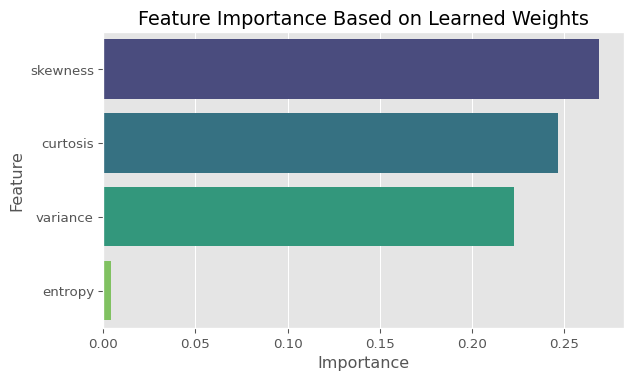

In [46]:
plt.figure(figsize=(7,4))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Feature Importance Based on Learned Weights")

save_fig("feature_importance")
plt.show()


In [47]:
top_features = importance["Feature"].head(2).tolist()

print("Selected Features:")
print(top_features)


Selected Features:
['skewness', 'curtosis']


In [48]:
X_two = df[top_features]
y_two = df["class"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_two,
    y_two,
    test_size=0.2,
    random_state=42,
    stratify=y_two
)

scaler2 = StandardScaler()

X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)


In [49]:
boundary_model = Perceptron(
    learning_rate=0.01,
    epochs=100
)

boundary_model.fit(
    X_train2_scaled,
    y_train2.values
)


Training Perceptron
Epoch   1 | Errors: 375 | Bias: -0.0100
Epoch   2 | Errors: 363 | Bias: 0.0000
Epoch   3 | Errors: 380 | Bias: 0.0000
Epoch   4 | Errors: 367 | Bias: -0.0100
Epoch   5 | Errors: 366 | Bias: -0.0100
Epoch   6 | Errors: 373 | Bias: 0.0000
Epoch   7 | Errors: 360 | Bias: 0.0000
Epoch   8 | Errors: 364 | Bias: 0.0000
Epoch   9 | Errors: 365 | Bias: -0.0100
Epoch  10 | Errors: 378 | Bias: 0.0100
Epoch  11 | Errors: 378 | Bias: 0.0100
Epoch  12 | Errors: 381 | Bias: 0.0000
Epoch  13 | Errors: 358 | Bias: 0.0000
Epoch  14 | Errors: 366 | Bias: 0.0000
Epoch  15 | Errors: 378 | Bias: 0.0000
Epoch  16 | Errors: 377 | Bias: -0.0100
Epoch  17 | Errors: 363 | Bias: 0.0000
Epoch  18 | Errors: 359 | Bias: -0.0100
Epoch  19 | Errors: 359 | Bias: 0.0000
Epoch  20 | Errors: 371 | Bias: -0.0100
Epoch  21 | Errors: 367 | Bias: 0.0000
Epoch  22 | Errors: 381 | Bias: 0.0100
Epoch  23 | Errors: 376 | Bias: -0.0100
Epoch  24 | Errors: 376 | Bias: -0.0100
Epoch  25 | Errors: 357 | Bias: 0.0

Epoch  29 | Errors: 364 | Bias: 0.0000
Epoch  30 | Errors: 356 | Bias: 0.0000
Epoch  31 | Errors: 372 | Bias: 0.0000
Epoch  32 | Errors: 375 | Bias: -0.0100


Epoch  33 | Errors: 357 | Bias: 0.0000
Epoch  34 | Errors: 357 | Bias: -0.0100
Epoch  35 | Errors: 378 | Bias: -0.0100
Epoch  36 | Errors: 359 | Bias: 0.0000
Epoch  37 | Errors: 370 | Bias: 0.0000
Epoch  38 | Errors: 368 | Bias: 0.0000
Epoch  39 | Errors: 364 | Bias: 0.0000
Epoch  40 | Errors: 371 | Bias: -0.0100
Epoch  41 | Errors: 381 | Bias: 0.0000
Epoch  42 | Errors: 372 | Bias: 0.0000
Epoch  43 | Errors: 376 | Bias: 0.0000
Epoch  44 | Errors: 369 | Bias: -0.0100
Epoch  45 | Errors: 367 | Bias: 0.0000
Epoch  46 | Errors: 381 | Bias: 0.0100
Epoch  47 | Errors: 379 | Bias: 0.0000
Epoch  48 | Errors: 368 | Bias: 0.0000
Epoch  49 | Errors: 362 | Bias: 0.0000
Epoch  50 | Errors: 367 | Bias: -0.0100
Epoch  51 | Errors: 362 | Bias: -0.0100
Epoch  52 | Errors: 359 | Bias: 0.0000
Epoch  53 | Errors: 371 | Bias: -0.0100
Epoch  54 | Errors: 367 | Bias: 0.0000
Epoch  55 | Errors: 372 | Bias: 0.0000
Epoch  56 | Errors: 372 | Bias: 0.0000
Epoch  57 | Errors: 371 | Bias: -0.0100
Epoch  58 | Error

Epoch  62 | Errors: 370 | Bias: 0.0000
Epoch  63 | Errors: 366 | Bias: 0.0000
Epoch  64 | Errors: 381 | Bias: 0.0100
Epoch  65 | Errors: 376 | Bias: -0.0100


Epoch  66 | Errors: 376 | Bias: -0.0100
Epoch  67 | Errors: 363 | Bias: 0.0000
Epoch  68 | Errors: 374 | Bias: 0.0000
Epoch  69 | Errors: 366 | Bias: 0.0000
Epoch  70 | Errors: 360 | Bias: 0.0000
Epoch  71 | Errors: 362 | Bias: 0.0000
Epoch  72 | Errors: 367 | Bias: -0.0100
Epoch  73 | Errors: 372 | Bias: -0.0100
Epoch  74 | Errors: 365 | Bias: 0.0000
Epoch  75 | Errors: 362 | Bias: 0.0000
Epoch  76 | Errors: 367 | Bias: -0.0100
Epoch  77 | Errors: 362 | Bias: -0.0100
Epoch  78 | Errors: 359 | Bias: 0.0000
Epoch  79 | Errors: 371 | Bias: -0.0100
Epoch  80 | Errors: 367 | Bias: 0.0000
Epoch  81 | Errors: 372 | Bias: 0.0000
Epoch  82 | Errors: 377 | Bias: -0.0100
Epoch  83 | Errors: 367 | Bias: 0.0000
Epoch  84 | Errors: 356 | Bias: 0.0000
Epoch  85 | Errors: 371 | Bias: -0.0100
Epoch  86 | Errors: 379 | Bias: 0.0000
Epoch  87 | Errors: 368 | Bias: 0.0000
Epoch  88 | Errors: 356 | Bias: 0.0000
Epoch  89 | Errors: 367 | Bias: -0.0100
Epoch  90 | Errors: 370 | Bias: -0.0100
Epoch  91 | Err

Epoch  95 | Errors: 365 | Bias: -0.0100
Epoch  96 | Errors: 379 | Bias: 0.0000
Epoch  97 | Errors: 356 | Bias: 0.0000
Epoch  98 | Errors: 371 | Bias: -0.0100


Epoch  99 | Errors: 388 | Bias: -0.0100
Epoch 100 | Errors: 368 | Bias: -0.0100


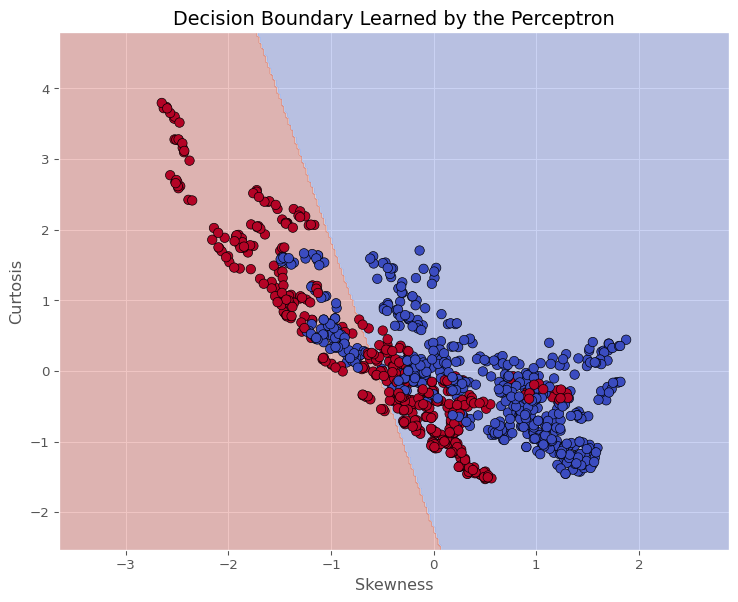

In [50]:
x_min, x_max = X_train2_scaled[:, 0].min() - 1, X_train2_scaled[:, 0].max() + 1
y_min, y_max = X_train2_scaled[:, 1].min() - 1, X_train2_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = boundary_model.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9,7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap="coolwarm"
)

scatter = plt.scatter(
    X_train2_scaled[:,0],
    X_train2_scaled[:,1],
    c=y_train2,
    cmap="coolwarm",
    edgecolors="black",
    s=50
)

plt.xlabel(top_features[0].capitalize())
plt.ylabel(top_features[1].capitalize())

plt.title("Decision Boundary Learned by the Perceptron")

save_fig("decision_boundary")
plt.show()
